In [15]:
import h5py
import pandas as pd
h5_file_path = "./LUT/SWRTM_case2_54layers_dnu=3_AOD=0.1243.h5"
csv_file_path = "./LUT/SWRTM_case2_54layers_dnu=3_AOD=0.1243.csv"
with h5py.File(h5_file_path, 'r') as h5_file:
    columns = [col.decode('utf-8') for col in h5_file['data/axis0'][:]]
    data = h5_file['data/block0_values'][:]
df = pd.DataFrame(data, columns=columns)
df = df[df['Ta'] >= 233]
df.to_csv(csv_file_path, index=False, encoding='utf-8')

Data split 7:3 training dataset: testing dataset

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
csv_file_path = "./LUT/SWRTM_case2_54layers_dnu=3_AOD=0.1243.csv"
df = pd.read_csv(csv_file_path)
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)
train_file_path = "./LUT/SWRTM_train.csv"
test_file_path = "./LUT/SWRTM_test.csv"
train_df.to_csv(train_file_path, index=False)  
test_df.to_csv(test_file_path, index=False)  


Correlation analysis

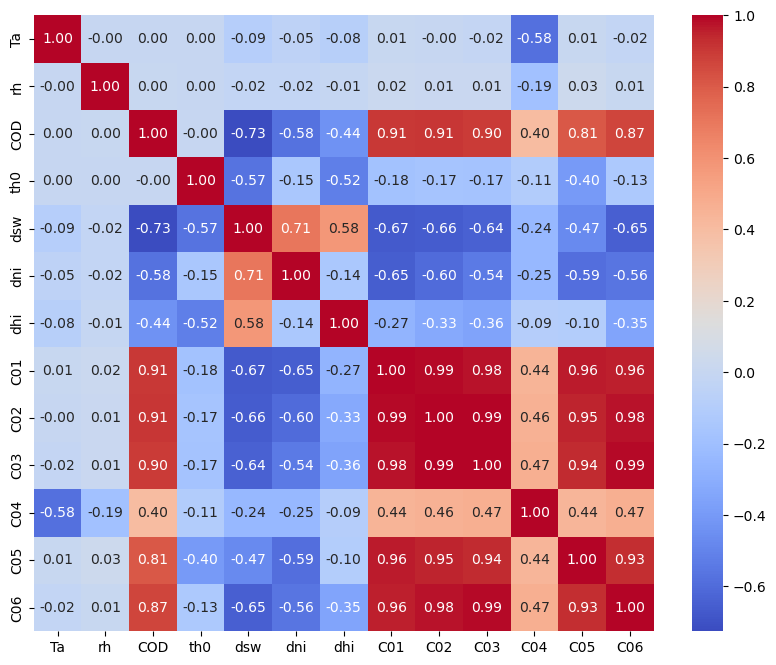

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
csv_file_path = "./LUT/SWRTM_case2_54layers_dnu=3_AOD=0.1243.csv"
df = pd.read_csv(csv_file_path)
correlation_matrix = df.corr()
#print(correlation_matrix)
plt.figure(figsize=(10, 8)) 
sns.heatmap(correlation_matrix, 
            annot=True,     
            fmt=".2f",      
            cmap="coolwarm", 
            cbar=True)        
plt.show()

# Gaussian Process Regression fitting using sklearn GPR model

A flexible, classical machine learning method that makes predictions based on observed patterns in your data and gives you both a predicted COD and an estimate of confidence or uncertainty for every prediction.

It tries to fit a smooth function through your data, using a mathematical structure (“kernel”) that describes how points relate to one another.

Key feature: 

- Very good for moderate-sized datasets
- Provides uncertainty estimates 

In [7]:
data

,Ta,rh,COD,th0,dsw,dni,dhi,C01,C02,C03,C04,C05,C06
0,238.0,0.2,3.98,15.0,882.611097,48.799843,835.474069,16.900747,25.674005,10.918653,0.822339,3.421025,0.794411
1,298.0,1.0,0.40,30.0,798.410211,480.117371,382.616371,9.249159,12.577447,8.444861,0.001853,2.642520,0.541604
2,253.0,1.0,1.58,60.0,367.824638,61.062861,337.293208,10.836514,14.864518,6.423871,0.040610,2.050034,0.490734
3,263.0,1.0,2.51,0.0,960.886520,82.717997,878.168523,13.897455,21.042494,10.490272,0.016614,3.292791,0.753286
4,228.0,0.5,3.98,0.0,934.679098,24.162471,910.516628,16.914538,25.742084,11.182935,0.875346,3.469120,0.806703
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10559,233.0,0.2,1.00,15.0,1038.613699,392.427786,659.557566,10.367687,14.689907,9.017062,0.788721,2.859052,0.654288
10560,288.0,0.5,50.00,30.0,150.406312,3.066922,147.750279,57.819745,152.456232,83.423363,0.025021,6.003394,4.291916
10561,248.0,0.2,3.98,0.0,922.375175,23.992861,898.382314,16.909748,25.673190,11.134425,0.592388,3.462578,0.804324
10562,273.0,0.3,0.40,0.0,1044.886252,578.372694,466.513558,9.103355,13.087189,8.912724,0.022388,2.883284,0.662905


In [ ]:
import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import joblib
file_path = "./LUT/SWRTM_train.csv"
data = pd.read_csv(file_path)

print(f"Original data size: {len(data)}")
if len(data) > 2000:
    data_train = data.sample(n=2000, random_state=42).reset_index(drop=True)
    print("Subsampled to 2000 rows for rapid training.")
else:
    data_train = data
# process
data['th0'] = np.cos(np.radians(data['th0'])) 
F_dw_os_srf_channel = [100.56360014402173,293.8703639771758,146.06104052297425,
                           12.06884597258561,13.936208329862962,18.20438461023419]
channels = ['C01', 'C02', 'C03', 'C04', 'C05', 'C06']
data[channels] = data[channels].div(F_dw_os_srf_channel)

X = data[['Ta', 'COD','rh', 'th0']].values
y = data[['C01', 'C02', 'C03', 'C04', 'C05', 'C06']].values
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y)#.ravel()
scaler_X_file = "./GUI/scaler_X.pkl"
scaler_y_file = "./GUI/scaler_y.pkl"
joblib.dump(scaler_X, scaler_X_file)
joblib.dump(scaler_y, scaler_y_file)
kernel = C(1.0, (1e-2, 1e2)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=1e-5)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)
gpr.fit(X, y)
print(gpr.kernel_)

Original data size: 8884
Subsampled to 2000 rows for rapid training.


Save model

In [21]:
model_path = "./GUI/gpr_model.pkl"
joblib.dump(gpr, model_path)

['./GUI/gpr_model.pkl']

Test model

In [10]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

RMSE: 0.1237
MAE: 0.0786
R²: 0.9999


Plot random sample

## further improvement

In [ ]:
import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import matplotlib.pyplot as plt

# --- 1. Load and Process Data ---
file_path = "./LUT/SWRTM_train.csv"
data = pd.read_csv(file_path)

# Feature engineering
data['th0'] = np.cos(np.radians(data['th0']))
F_dw_os_srf_channel = [74.87, 134.24, 33.70, 4.92, 11.08, 3.52]
channels = ['C01', 'C02', 'C03', 'C04', 'C05', 'C06']
data[channels] = data[channels].div(F_dw_os_srf_channel)

X = data[['Ta', 'rh', 'th0', 'C01', 'C02', 'C03', 'C04', 'C05', 'C06']].values
y = data[['COD']].values

# --- 2. Split data into a training and validation set ---
# This lets us check model performance before the final test
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 3. Scale Data ---
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Fit on training data ONLY
X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train).ravel()

# Transform validation data
X_val_scaled = scaler_X.transform(X_val)

# --- 4. Define and Train the Improved GPR Model ---
n_features = X_train_scaled.shape[1]

# ✅ Use an ANISOTROPIC kernel (a length_scale for each feature)
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[1.0] * n_features, length_scale_bounds=(1e-2, 1e3)) \
         + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1))

gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)

print("Fitting improved GPR model...")
gpr.fit(X_train_scaled, y_train_scaled)

print("\n--- Optimized Kernel Parameters ---")
print(gpr.kernel_)

# --- 5. Evaluate on the Validation Set ---
y_pred_scaled = gpr.predict(X_val_scaled)
mae = mean_absolute_error(y_test, y_pred)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

r2 = r2_score(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

print(f"\n--- Model Performance on Validation Set ---")
print(f"MAE: {mae:.4f}")
print(f"R-squared (R2): {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# --- 6. Save the NEW, IMPROVED Model and Scalers ---
print("\nSaving new model and scalers...")
joblib.dump(gpr, "./GUI/gpr_model_improved.pkl")
joblib.dump(scaler_X, "./GUI/scaler_X_improved.pkl")
joblib.dump(scaler_y, "./GUI/scaler_y_improved.pkl")

print("Done. Now use these improved files in your testing script.")

Fitting improved GPR model...


/Users/dengnan/anaconda3/envs/python37/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/dengnan/anaconda3/envs/python37/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/dengnan/anaconda3/envs/python37/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 6 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn


--- Optimized Kernel Parameters ---
0.712**2 * RBF(length_scale=[1e+03, 1e+03, 0.611, 0.0868, 0.43, 0.739, 1e+03, 1.83, 15.2]) + WhiteKernel(noise_level=1e-05)

--- Model Performance on Validation Set ---
R-squared (R2): 1.0000
Root Mean Squared Error (RMSE): 0.0296

Saving new model and scalers...
Done. Now use these improved files in your testing script.


0.03104244729118151


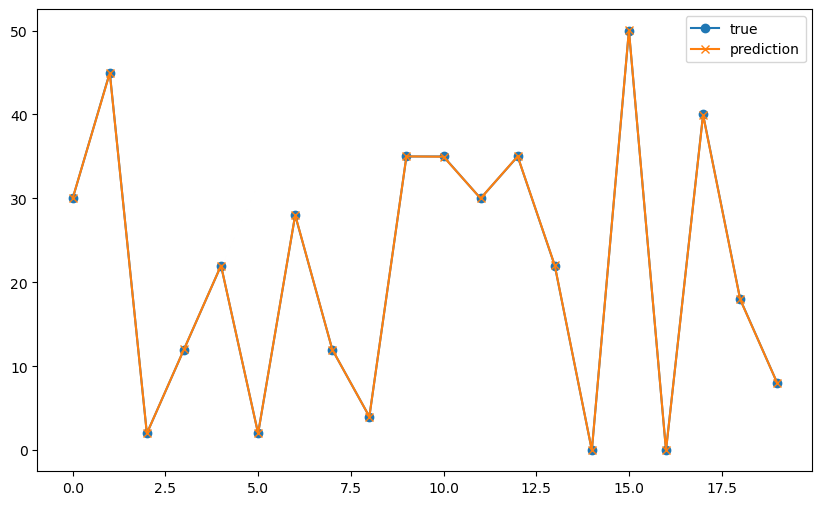

In [17]:
gpr_loaded = joblib.load("./GUI/gpr_model_improved.pkl")
file_path = "./SWRTM_test.csv"
data_test = pd.read_csv(file_path)
data_test['th0'] = np.cos(np.radians(data_test['th0'])) 

F_dw_os_srf_channel = [74.87, 134.24, 33.70, 4.92, 11.08, 3.52]
channels = ['C01', 'C02', 'C03', 'C04', 'C05', 'C06']
data_test[channels] = data_test[channels].div(F_dw_os_srf_channel)

X_test = data_test[['Ta', 'rh', 'th0', 'C01', 'C02', 'C03', 'C04', 'C05', 'C06']].values
y_test = data_test[['COD']].values
scaler_X = joblib.load("./GUI/scaler_X_improved.pkl")
scaler_y = joblib.load("./GUI/scaler_y_improved.pkl")
X_test = scaler_X.transform(X_test) 
y_test_std = scaler_y.transform(y_test)
y_pred_std, y_std = gpr_loaded.predict(X_test, return_std=True)
y_pred = scaler_y.inverse_transform(y_pred_std.reshape(-1, 1)).ravel()
y_test = scaler_y.inverse_transform(y_test_std.reshape(-1, 1)).ravel()
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(rmse)
results = pd.DataFrame({
    'true': y_test,
    'prediction': y_pred
})

import random
random_indices = random.sample(range(len(y_test)), 20)
y_test_sample = y_test[random_indices]
y_pred_sample = y_pred[random_indices]
y_std_sample = y_std[random_indices]
plt.figure(figsize=(10, 6))
plt.plot(range(20), y_test_sample, label="true", marker='o')
plt.plot(range(20), y_pred_sample, label="prediction", marker='x')
plt.fill_between(range(20), 
                 (y_pred_sample.ravel() - 1.96 * y_std_sample), 
                 (y_pred_sample.ravel() + 1.96 * y_std_sample), 
                 )

plt.legend()
plt.show()

# Test with real satellite data

In [1]:
import os
import pandas as pd
import numpy as np
from scipy import interpolate
from itertools import chain
from multiprocessing import Pool
import re
import h5py
import time
import matplotlib.pyplot as plt

data_dir = '../GOES_data/'  #'./lut_test_file/'
spectral = 'SW'
phase = 'water' #'water' clearsky
N_bundles = 1000
timeofday = 'day'  # 'day' or 'night'
figlabels = ['COD<10', 'COD>20', 'COD<10']  #July13
Sat_dir = 'GOES16_site_sat_data'
sky = 'day'

file_dir = './retrived_results/'  # Directory to save results

for figlabel in figlabels:
    sat = pd.read_hdf(os.path.join(data_dir + Sat_dir,
                     "GOES_{}_BON_radiance_satellite_{}_{}_{}.h5".format(timeofday, phase, figlabel, sky)),
                    'df')
    sat['temp']= sat['temp'] + 273.15
    sat['rh'] = sat['rh']/100
    sat.rename(columns={'temp': 'Ta', 'Sun_Zen': 'th0'}, inplace=True)
    sat['COD_pre'] = sat.apply(Rad_to_Flux_sug_COD, axis=1)
    
    sat.to_csv(file_dir + f"Result_BON_{sky}_radiance_satellite_{phase}_{figlabel}.csv", index=False)

# PCA

In [2]:
import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ... (Load your data as before) ...
file_path = "./LUT/SWRTM_train.csv"
data = pd.read_csv(file_path)
# process
data['th0'] = np.cos(np.radians(data['th0'])) 
F_dw_os_srf_channel = [100.56360014402173,293.8703639771758,146.06104052297425,
                           12.06884597258561,13.936208329862962,18.20438461023419]
channels = ['C01', 'C02', 'C03', 'C04', 'C05', 'C06']
data[channels] = data[channels].div(F_dw_os_srf_channel)
X = data[['Ta', 'rh', 'th0', 'COD']].values
y = data[['C01', 'C02', 'C03', 'C04', 'C05', 'C06']].values

# Scale inputs X
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

# Scale targets y (Important before PCA)
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y)

# Apply PCA to keep the channels "fixed" together
# n_components=0.999 means "Keep enough components to explain 99.9% of the variance"
# Usually for 6 RTM channels, this might just be 2 or 3 components.
pca = PCA(n_components=0.999) 
y_pca = pca.fit_transform(y_scaled)

print(f"Original y shape: {y.shape}")   # (N, 6)
print(f"PCA y shape: {y_pca.shape}")     # (N, 3) <- Probably reduced to 3 columns
print(f"Explained Variance: {pca.explained_variance_ratio_}")

# --- STEP 2: TRAIN GPR ON THE COMPRESSED VECTOR ---

# Kernel for the PCA components
kernel = C(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=1e-4)

# Train on y_pca, not the raw y
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=2, random_state=42)

print("Training GPR on PCA components...")
gpr.fit(X_scaled, y_pca)
print("Training complete.")

# --- STEP 3: PREDICTION & RECONSTRUCTION ---

def predict_spectrum(new_X_raw):
    # 1. Scale Input
    X_new_scaled = scaler_X.transform(new_X_raw)
    
    # 2. Predict PCA components
    y_pred_pca = gpr.predict(X_new_scaled)
    
    # 3. Inverse PCA (Reconstruct the 6 channels)
    y_pred_scaled = pca.inverse_transform(y_pred_pca)
    
    # 4. Inverse Scale (Get back to physical units)
    y_pred_final = scaler_y.inverse_transform(y_pred_scaled)
    
    return y_pred_final

# Test with the first 5 rows of training data
test_prediction = predict_spectrum(X[:5])
print("Predicted 6 channels (fixed to each other):\n", test_prediction)

Original y shape: (8884, 6)
PCA y shape: (8884, 5)
Explained Variance: [0.85301103 0.12512588 0.01472289 0.00591542 0.00122096]
Training GPR on PCA components...


/Users/dengnan/anaconda3/envs/python37/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Training complete.
Predicted 6 channels (fixed to each other):
 [[8.05193310e-02 3.63927573e-02 5.20365643e-02 1.76534423e-04
  1.79265989e-01 2.98115080e-02]
 [3.59400142e-01 3.27839939e-01 3.90479842e-01 8.10469980e-02
  3.45186168e-01 2.19147315e-01]
 [5.05322515e-01 4.69879402e-01 5.47268928e-01 7.06330876e-02
  4.53943987e-01 2.57207818e-01]
 [1.03419076e-01 5.07832885e-02 6.20191612e-02 2.52195001e-02
  2.06961317e-01 3.66508212e-02]
 [3.29318587e-01 2.94247267e-01 3.41495288e-01 5.22627841e-02
  2.77802082e-01 1.78478954e-01]]


In [3]:
import joblib
import os

# 1. Create a dictionary containing all components
model_bundle = {
    'scaler_X': scaler_X,
    'scaler_y': scaler_y,
    'pca': pca,
    'gpr_model': gpr,
    'metadata': {
        'description': 'SWRTM Emulator with PCA+GPR',
        'date': '2025-11-20',
        'input_columns': ['Ta', 'rh', 'th0', 'COD'],
        'output_channels': ['C01', 'C02', 'C03', 'C04', 'C05', 'C06']
    }
}

# 2. Define save path
save_dir = "./GUI/"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    
save_path = os.path.join(save_dir, "SWRTM_PCA_GPR_v1.pkl")

# 3. Save to disk
joblib.dump(model_bundle, save_path)

print(f"Model pipeline successfully saved to: {save_path}")

Model pipeline successfully saved to: ./GUI/SWRTM_PCA_GPR_v1.pkl


In [ ]:
import joblib
import numpy as np

# 1. Load the bundle
model_path = "./GUI/SWRTM_PCA_GPR_v1.pkl"
print(f"Loading model from {model_path}...")

loaded_bundle = joblib.load(model_path)

# 2. Extract the components back into variables
scaler_X = loaded_bundle['scaler_X']
scaler_y = loaded_bundle['scaler_y']
pca      = loaded_bundle['pca']
gpr      = loaded_bundle['gpr_model']

print("Model loaded successfully!")

# 3. Re-define the prediction function using these loaded objects
def predict_spectrum_loaded(new_X_raw):
    """
    Input: Array of shape (N, 4) -> [Ta, rh, th0, COD]
    Output: Array of shape (N, 6) -> [C01 ... C06]
    """
    # A. Scale Input (Using the loaded scaler)
    X_new_scaled = scaler_X.transform(new_X_raw)
    
    # B. Predict PCA components (Using the loaded GPR)
    y_pred_pca = gpr.predict(X_new_scaled)
    
    # C. Inverse PCA (Reconstruct the 6 channels)
    y_pred_scaled = pca.inverse_transform(y_pred_pca)
    
    # D. Inverse Scale (Get back to physical units)
    y_pred_final = scaler_y.inverse_transform(y_pred_scaled)
    
    return y_pred_final

# --- TEST IT ---
# Example input: Ta=290K, rh=0.5, th0=0.8, COD=10
file_path = "./LUT/SWRTM_test.csv"
data_test = pd.read_csv(file_path)
data_test['th0'] = np.cos(np.radians(data_test['th0'])) 

F_dw_os_srf_channel = [100.56360014402173,293.8703639771758,146.06104052297425,
                           12.06884597258561,13.936208329862962,18.20438461023419]
channels = ['C01', 'C02', 'C03', 'C04', 'C05', 'C06']
data_test[channels] = data_test[channels].div(F_dw_os_srf_channel)

X_test = data_test[['Ta', 'rh', 'th0', 'COD']].values
y_test = data_test[['C01', 'C02', 'C03', 'C04', 'C05', 'C06']].values

y_pred = predict_spectrum_loaded(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(rmse)
results = pd.DataFrame({
    'true': y_test,
    'prediction': y_pred
})

In [ ]:


scaler_X = joblib.load("./GUI/scaler_X_improved.pkl")
scaler_y = joblib.load("./GUI/scaler_y_improved.pkl")
X_test = scaler_X.transform(X_test) 
y_test_std = scaler_y.transform(y_test)
y_pred_std, y_std = gpr_loaded.predict(X_test, return_std=True)
y_pred = scaler_y.inverse_transform(y_pred_std.reshape(-1, 1)).ravel()
y_test = scaler_y.inverse_transform(y_test_std.reshape(-1, 1)).ravel()
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(rmse)
results = pd.DataFrame({
    'true': y_test,
    'prediction': y_pred
})

import random
random_indices = random.sample(range(len(y_test)), 20)
y_test_sample = y_test[random_indices]
y_pred_sample = y_pred[random_indices]
y_std_sample = y_std[random_indices]
plt.figure(figsize=(10, 6))
plt.plot(range(20), y_test_sample, label="true", marker='o')
plt.plot(range(20), y_pred_sample, label="prediction", marker='x')
plt.fill_between(range(20), 
                 (y_pred_sample.ravel() - 1.96 * y_std_sample), 
                 (y_pred_sample.ravel() + 1.96 * y_std_sample), 
                 )

plt.legend()
plt.show()

# Other

### 2. 2nd improvement

In [ ]:
import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import matplotlib.pyplot as plt

# --- 1. Load and Process Data ---
file_path = "./SWRTM_train.csv"
data = pd.read_csv(file_path)

# Feature engineering
data['th0'] = np.cos(np.radians(data['th0']))
F_dw_os_srf_channel = [74.87, 134.24, 33.70, 11.08, 3.52] #74.87, 134.24, 33.70, 4.92, 11.08, 3.52
channels = ['C01', 'C02', 'C03', 'C05', 'C06']
data[channels] = data[channels].div(F_dw_os_srf_channel)

X = data[['Ta', 'rh', 'th0', 'C01', 'C02', 'C03', 'C05', 'C06']].values
y = data[['COD']].values

# --- 2. Split data into a training and validation set ---
# This lets us check model performance before the final test
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 3. Scale Data ---
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Fit on training data ONLY
X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train).ravel()

# Transform validation data
X_val_scaled = scaler_X.transform(X_val)

# --- 4. Define and Train the Improved GPR Model ---
n_features = X_train_scaled.shape[1]

# ✅ Use an ANISOTROPIC kernel (a length_scale for each feature)
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[1.0] * n_features, length_scale_bounds=(1e-2, 1e3)) \
         + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1))

gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)

print("Fitting improved GPR model...")
gpr.fit(X_train_scaled, y_train_scaled)

print("\n--- Optimized Kernel Parameters ---")
print(gpr.kernel_)

# --- 5. Evaluate on the Validation Set ---
y_pred_scaled = gpr.predict(X_val_scaled)
mae = mean_absolute_error(y_test, y_pred)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

r2 = r2_score(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

print(f"\n--- Model Performance on Validation Set ---")
print(f"MAE: {mae:.4f}")
print(f"R-squared (R2): {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# --- 6. Save the NEW, IMPROVED Model and Scalers ---
print("\nSaving new model and scalers...")
joblib.dump(gpr, "./GUI/gpr_model_improved_5c.pkl")
joblib.dump(scaler_X, "./GUI/scaler_X_improved_5c.pkl")
joblib.dump(scaler_y, "./GUI/scaler_y_improved_5c.pkl")

print("Done. Now use these improved files in your testing script.")

Fitting improved GPR model...


/Users/dengnan/anaconda3/envs/python37/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/dengnan/anaconda3/envs/python37/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/dengnan/anaconda3/envs/python37/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(



--- Optimized Kernel Parameters ---
0.72**2 * RBF(length_scale=[1e+03, 1e+03, 0.614, 0.0868, 0.433, 0.746, 1.83, 15.4]) + WhiteKernel(noise_level=1e-05)

--- Model Performance on Validation Set ---
MAE: 0.0025
R-squared (R2): 1.0000
Root Mean Squared Error (RMSE): 0.0295

Saving new model and scalers...
Done. Now use these improved files in your testing script.


#### COD<10 cases

Original test set size: 2016
Filtered test set size (COD < 10): 523

RMSE for COD < 10 cases: 0.0040


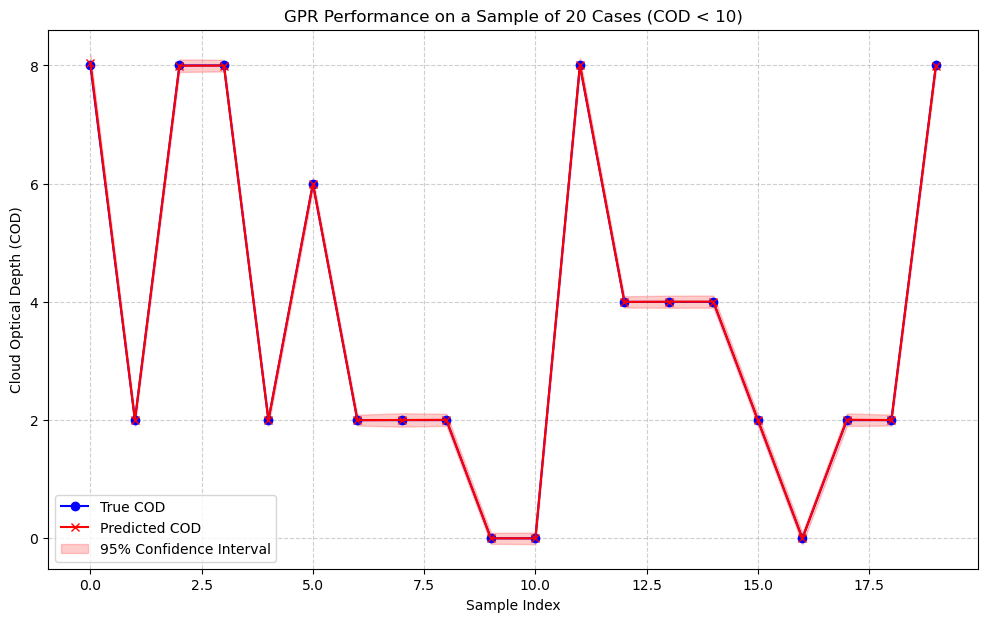

In [18]:
import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
from sklearn.metrics import mean_squared_error
import joblib
import matplotlib.pyplot as plt
import random

# --- Load Model and Scalers ---
gpr_loaded = joblib.load("./GUI/gpr_model_improved.pkl")
scaler_X = joblib.load("./GUI/scaler_X_improved.pkl")
scaler_y = joblib.load("./GUI/scaler_y_improved.pkl")

# --- Load and Filter Data ---
file_path = "./SWRTM_test.csv"
data_test = pd.read_csv(file_path)

print(f"Original test set size: {len(data_test)}")

# ✅ FIX: Filter the DataFrame for cases where COD is less than 10
data_test = data_test[data_test['COD'] < 10].copy()

print(f"Filtered test set size (COD < 10): {len(data_test)}")

if len(data_test) == 0:
    print("No data found with COD < 10. Exiting.")
else:
    # --- Preprocess the Filtered Data ---
    data_test['th0'] = np.cos(np.radians(data_test['th0']))

    F_dw_os_srf_channel = [74.87, 134.24, 33.70, 4.92, 11.08, 3.52]
    channels = ['C01', 'C02', 'C03', 'C04', 'C05', 'C06']
    data_test[channels] = data_test[channels].div(F_dw_os_srf_channel)

    # --- Prepare X and y from the Filtered Data ---
    X_test = data_test[['Ta', 'rh', 'th0', 'C01', 'C02', 'C03', 'C04', 'C05', 'C06']].values
    y_test = data_test[['COD']].values

    # --- Scale, Predict, and Evaluate ---
    X_test_scaled = scaler_X.transform(X_test)
    
    y_pred_std, y_std = gpr_loaded.predict(X_test_scaled, return_std=True)
    
    # Inverse transform to get values in original scale
    y_pred = scaler_y.inverse_transform(y_pred_std.reshape(-1, 1)).ravel()

    # Calculate RMSE on the filtered subset
    rmse = np.sqrt(mean_squared_error(y_test.ravel(), y_pred))
    print(f"\nRMSE for COD < 10 cases: {rmse:.4f}")

    # --- Plot a Sample from the Filtered Results ---
    num_samples_to_plot = min(20, len(y_test))
    random_indices = random.sample(range(len(y_test)), num_samples_to_plot)

    y_test_sample = y_test.ravel()[random_indices]
    y_pred_sample = y_pred[random_indices]
    
    # The standard deviation from the GPR is in scaled units.
    # We need to scale it by the standard deviation of the target variable.
    y_std_unscaled = y_std * scaler_y.scale_
    y_std_sample = y_std_unscaled[random_indices]
    
    plt.figure(figsize=(12, 7))
    plt.plot(range(num_samples_to_plot), y_test_sample, 'o-', label="True COD", color='blue')
    plt.plot(range(num_samples_to_plot), y_pred_sample, 'x-', label="Predicted COD", color='red')
    
    # Add uncertainty interval (95% confidence)
    plt.fill_between(range(num_samples_to_plot),
                     y_pred_sample - 1.96 * y_std_sample,
                     y_pred_sample + 1.96 * y_std_sample,
                     color='red', alpha=0.2, label='95% Confidence Interval')

    plt.title(f"GPR Performance on a Sample of {num_samples_to_plot} Cases (COD < 10)")
    plt.xlabel("Sample Index")
    plt.ylabel("Cloud Optical Depth (COD)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

## GHI, DNI

In [46]:
import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import os

def train_gpr_for_target(data, feature_cols, target_col):
    """
    Trains, evaluates, and saves a GPR model for a specific target variable.

    Args:
        data (pd.DataFrame): The full training dataframe.
        feature_cols (list): A list of column names to use as input features.
        target_col (str): The name of the target column to predict.
    """
    print(f"\n{'='*40}")
    print(f"🚀 Training Model for Target: {target_col}")
    print(f"{'='*40}")

    # --- 1. Define Features (X) and Target (y) ---
    X = data[feature_cols].values
    y = data[[target_col]].values

    # --- 2. Split data ---
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    # --- 3. Scale Data ---
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    y_train_scaled = scaler_y.fit_transform(y_train).ravel()
    X_val_scaled = scaler_X.transform(X_val)

    # --- 4. Define and Train the GPR Model ---
    n_features = X.shape[1]
    kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[1.0] * n_features, length_scale_bounds=(1e-2, 1e3)) \
             + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1e1))
    gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)

    print("Fitting GPR model...")
    gpr.fit(X_train_scaled, y_train_scaled)
    print(f"\nOptimized Kernel: {gpr.kernel_}")

    # --- 5. Evaluate on the Validation Set ---
    y_pred_scaled = gpr.predict(X_val_scaled)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

    r2 = r2_score(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))

    print(f"\n--- Validation Performance for {target_col} ---")
    print(f"R-squared (R2): {r2:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

    # --- 6. Save the Model and Scalers ---
    output_dir = "./GUI/"
    os.makedirs(output_dir, exist_ok=True) # Ensure the directory exists
    
    target_name = target_col.lower()
    joblib.dump(gpr, os.path.join(output_dir, f"gpr_model_{target_name}.pkl"))
    joblib.dump(scaler_X, os.path.join(output_dir, f"scaler_X_{target_name}.pkl"))
    joblib.dump(scaler_y, os.path.join(output_dir, f"scaler_y_{target_name}.pkl"))
    print(f"\n✅ Model and scalers for {target_col} saved successfully.")


# ==============================================================================
# Main script execution
# ==============================================================================

# --- Load and process data once ---
file_path = "./SWRTM_train.csv"
data = pd.read_csv(file_path)
# Perform feature engineering
data['th0'] = np.cos(np.radians(data['th0']))

# --- Define the new set of input features ---
feature_columns = ['Ta', 'rh', 'th0', 'COD', 'dsw', 'dni']

# --- Train a model for GHI ---
train_gpr_for_target(data=data, feature_cols=feature_columns, target_col='dsw')

# --- Train a second model for DNI ---
train_gpr_for_target(data=data, feature_cols=feature_columns, target_col='dni')


🚀 Training Model for Target: dsw
Fitting GPR model...


/Users/dengnan/anaconda3/envs/python37/lib/python3.10/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 15 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/dengnan/anaconda3/envs/python37/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/dengnan/anaconda3/envs/python37/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better va


Optimized Kernel: 4.43**2 * RBF(length_scale=[1e+03, 1e+03, 1e+03, 1e+03, 10.5, 1e+03]) + WhiteKernel(noise_level=1e-05)

--- Validation Performance for dsw ---
R-squared (R2): 1.0000
Root Mean Squared Error (RMSE): 0.0040

✅ Model and scalers for dsw saved successfully.

🚀 Training Model for Target: dni
Fitting GPR model...


/Users/dengnan/anaconda3/envs/python37/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/dengnan/anaconda3/envs/python37/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/dengnan/anaconda3/envs/python37/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn


Optimized Kernel: 4.43**2 * RBF(length_scale=[1e+03, 1e+03, 1e+03, 1e+03, 1e+03, 9.7]) + WhiteKernel(noise_level=1e-05)

--- Validation Performance for dni ---
R-squared (R2): 1.0000
Root Mean Squared Error (RMSE): 0.0041

✅ Model and scalers for dni saved successfully.


# MLP model 

Multi-Layer Perceptron / Neural Network

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
file_path = "./SWRTM_case2_54layers_dnu=3_AOD=0.1243.csv"
data = pd.read_csv(file_path)

# Feature engineering
data['th0'] = np.cos(np.radians(data['th0'])) 
F_dw_os_srf_channel = [100.56360014402173,293.8703639771758,146.06104052297425,
                           12.06884597258561,13.936208329862962,18.20438461023419]
channels = ['C01', 'C02', 'C03', 'C04', 'C05', 'C06']
data[channels] = data[channels].div(F_dw_os_srf_channel)

X = data[['Ta', 'COD','rh', 'th0']].values
y = data[['C01', 'C02', 'C03', 'C04', 'C05', 'C06']].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)
y_train = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

# ✅ ADD THE SAVING CODE RIGHT HERE
import joblib
scaler_X_path = "./MLP_model/scaler_X.pkl"
scaler_y_path = "./MLP_model/scaler_y.pkl"
joblib.dump(scaler_X, scaler_X_path)
joblib.dump(scaler_y, scaler_y_path)

class RTMDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
train_dataset = RTMDataset(X_train, y_train)
test_dataset = RTMDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )

    def forward(self, x):
        return self.model(x)

input_size = X_train.shape[1]  
hidden_size = 128              
output_size = 1             
model = MLP(input_size, hidden_size, output_size)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 100
train_losses = []
test_losses = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch).squeeze()
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch)
            test_loss += loss.item()

    test_loss /= len(test_loader)
    test_losses.append(test_loss)
    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")

ModuleNotFoundError: No module named 'torch'

Saving the well trained model

In [18]:
model_path = "./MLP_model/MLP_model.pth"
torch.save(model.state_dict(), model_path)

--- MLP Model Performance on Test Data ---
Root Mean Squared Error (RMSE): 0.2544
R-squared (R2 Score): 0.9997


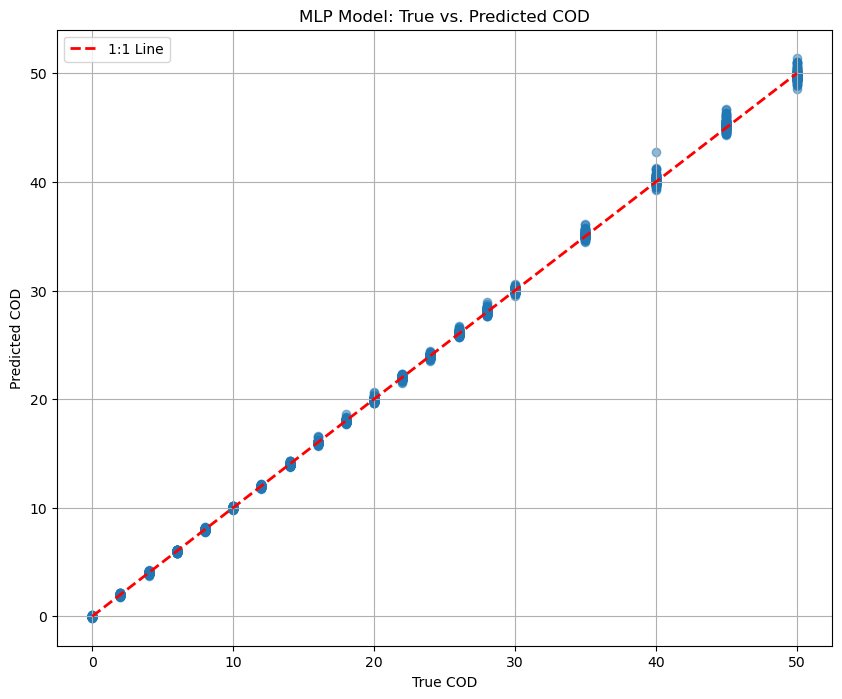

In [21]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import joblib

# --- 1. Define the MLP Model and Dataset Class ---
# This structure MUST be identical to the one you used for training
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )
    def forward(self, x):
        return self.model(x)

class RTMDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# --- 2. Load Model, Scalers, and Test Data ---
# Define model parameters
input_size = 9  # Number of input features
hidden_size = 128
output_size = 1

# Initialize model and load saved weights
model = MLP(input_size, hidden_size, output_size)
model.load_state_dict(torch.load("./MLP_model/MLP_model.pth"))
model.eval() # Set the model to evaluation mode

# Load the scalers
scaler_X = joblib.load("./MLP_model/scaler_X.pkl")
scaler_y = joblib.load("./MLP_model/scaler_y.pkl")

# Load and preprocess the new test data
test_file_path = "./SWRTM_test.csv"
data_test = pd.read_csv(test_file_path)
data_test['th0'] = np.cos(np.radians(data_test['th0']))
# Feature engineering
F_dw_os_srf_channel = [74.87, 134.24, 33.70, 4.92, 11.08, 3.52]
channels = ['C01', 'C02', 'C03', 'C04', 'C05', 'C06']
data_test[channels] = data_test[channels].div(F_dw_os_srf_channel)
X_test = data_test[['Ta', 'rh', 'th0', 'C01', 'C02', 'C03', 'C04', 'C05', 'C06']].values
y_test = data_test['COD'].values

# --- 3. Prepare Data for Evaluation ---
# Scale the test data using the loaded scalers
X_test_scaled = scaler_X.transform(X_test)

# Convert to PyTorch tensors
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

# --- 4. Make Predictions ---
all_preds = []
with torch.no_grad(): # Disable gradient calculations for inference
    predictions_scaled = model(X_test_tensor).squeeze()

# Inverse transform to get predictions in the original scale
y_pred = scaler_y.inverse_transform(predictions_scaled.numpy().reshape(-1, 1)).ravel()

# --- 5. Calculate and Print Metrics ---
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"--- MLP Model Performance on Test Data ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2 Score): {r2:.4f}")

# --- 6. Visualize the Results ---
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2, label='1:1 Line')
plt.title('MLP Model: True vs. Predicted COD')
plt.xlabel('True COD')
plt.ylabel('Predicted COD')
plt.grid(True)
plt.legend()
plt.show()

# The Symbolic Regression Model [PySR](https://arxiv.org/pdf/2305.01582)



A cutting-edge AI approach that tries to find explicit mathematical equations that relate your input variables to COD, like a “formula discovery” engine.

How it works:
- Starts with your input and COD data.
- Automatically searches for mathematical expressions (using operations like +, -, *, sin, exp, etc.) that best predict COD from the given features.
- After training, it outputs an actual readable mathematical expression, not just a black-box prediction.

Key features:
- Produces human-readable formulas, which help you understand the relationships in your data.
- Useful for scientific interpretation and model transparency.
- Can be visualized to compare model prediction vs. real values.

In [16]:
# you can try
import numpy as np
import pandas as pd
from pysr import PySRRegressor
file_path = r"./SWRTM_train.csv"
data = pd.read_csv(file_path)
data['th0'] = np.cos(np.radians(data['th0']))  
X = data[['Ta', 'rh', 'th0', 'C01', 'C02', 'C03', 'C04', 'C05', 'C06']].values
y = data[['COD']].values.ravel() 
model = PySRRegressor(
    niterations=1000,         
    populations=40,          
    population_size=1000,       
    variable_names=['Ta', 'rh', 'th0', 'C01', 'C02', 'C03', 'C04', 'C05', 'C06'],  
    progress=True,              
    loss='loss(x, y) = (x - y)^2',  
    maxsize=50,            
    verbosity=1,              
    random_state=42     
)

model.fit(X, y)
print(model)
y_pred = model.predict(X)
import matplotlib.pyplot as plt
plt.scatter(y, y_pred, alpha=0.7, label='Predicted vs True')
plt.plot([min(y), max(y)], [min(y), max(y)], color="red", label="Ideal Fit")
plt.xlabel("True COD")
plt.ylabel("Predicted COD")
plt.legend()
plt.show()

ModuleNotFoundError: No module named 'pysr'